   Gender  Age    Education  EmploymentYears  CreditScore  AnnualIncome  \
0    Male   27  High School               24          736         54786   
1  Female   52  High School               16          606         46055   
2  Female   39  High School                6          630        111190   
3  Female   26          PhD               18          842         73750   
4    Male   40       Master                6          740         88767   

   LoanAmount  ExistingLoans Married  LoanApproved  
0      148474              2      No             1  
1      252760              3     Yes             0  
2       77855              0     Yes             0  
3      129726              2     Yes             1  
4      302895              2     Yes             1  

Shape : (5000, 10)

Missing Values
Gender             0
Age                0
Education          0
EmploymentYears    0
CreditScore        0
AnnualIncome       0
LoanAmount         0
ExistingLoans      0
Married            0
LoanAp

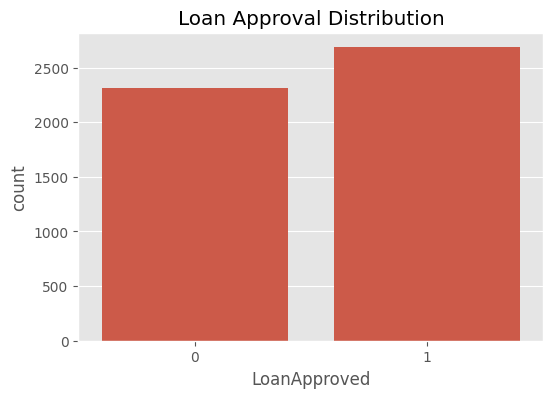

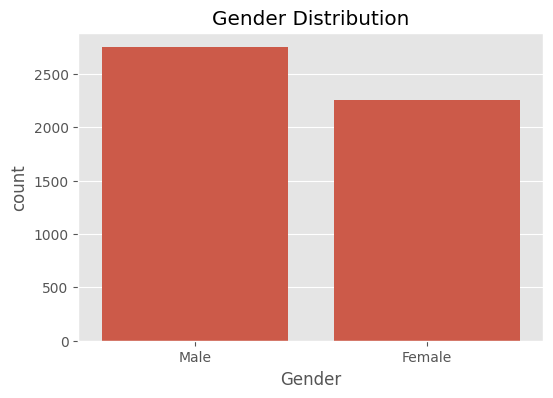

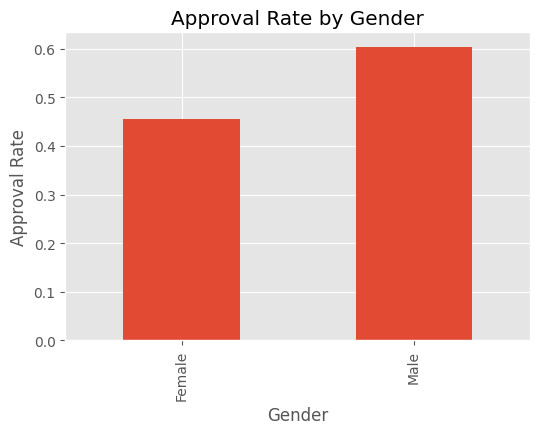

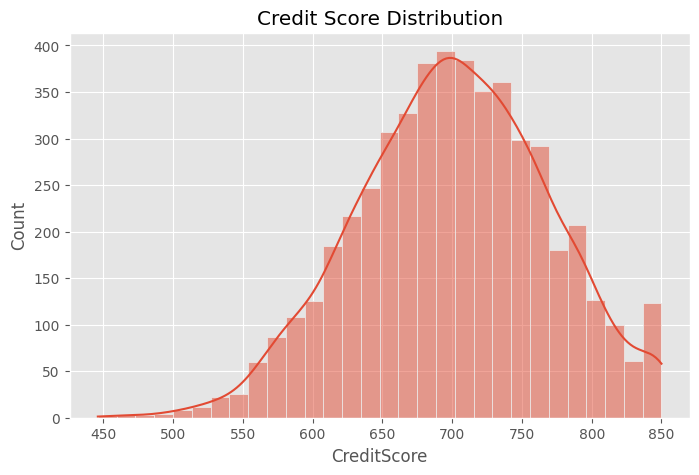

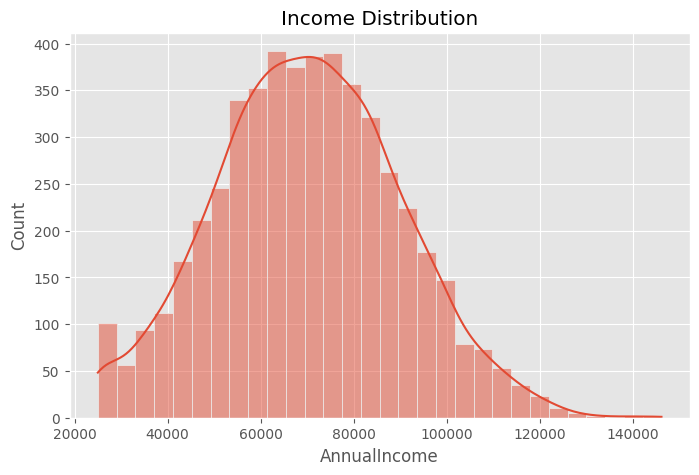

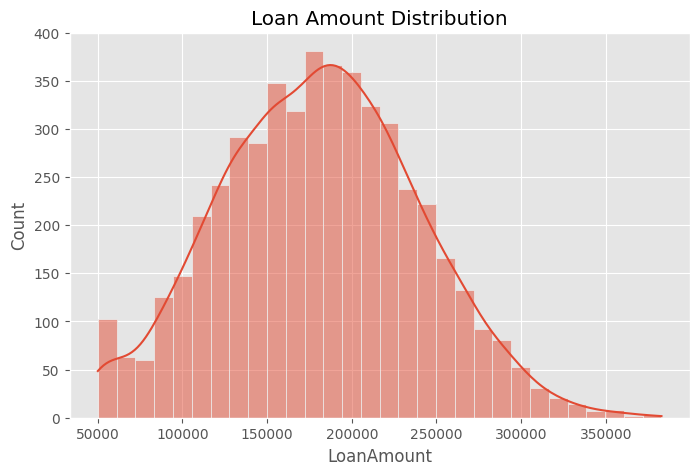

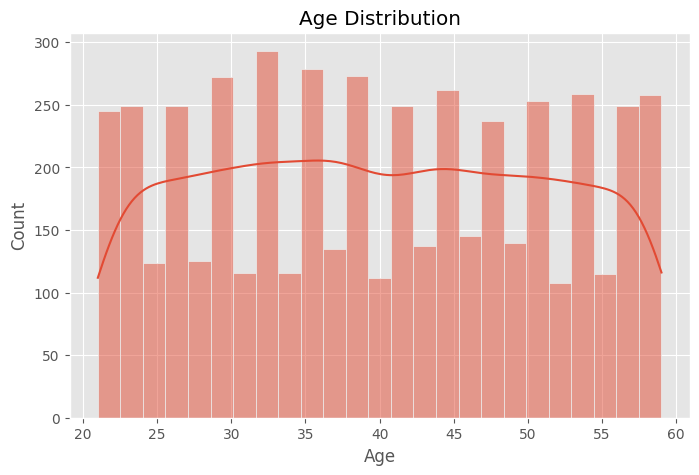

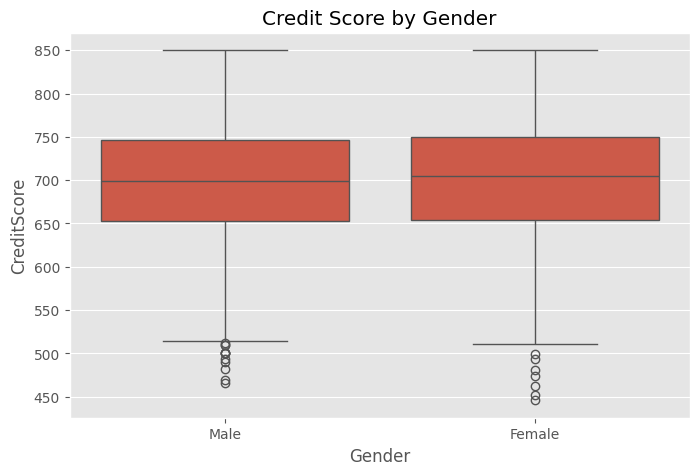

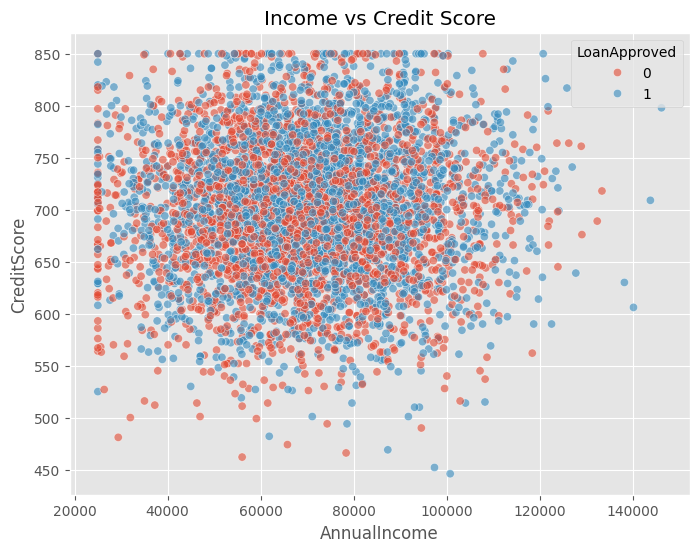

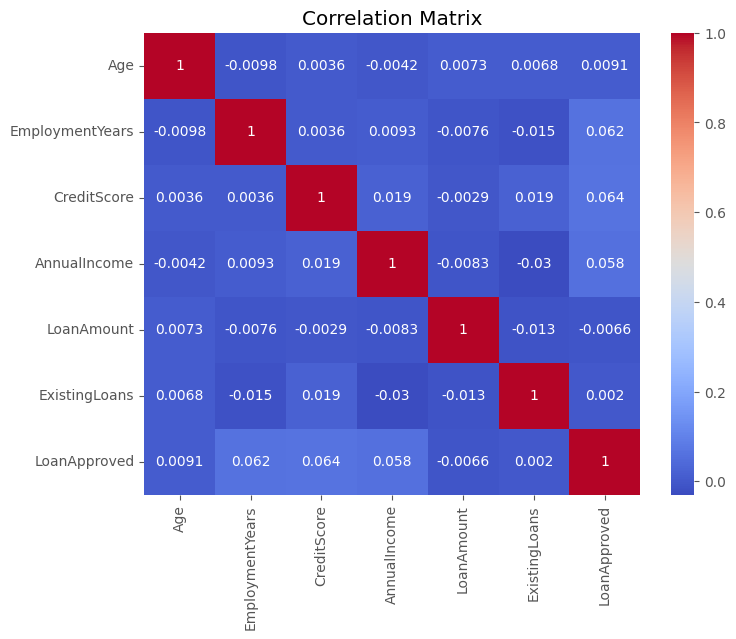


Approval Rate by Gender
Gender
Female    0.456039
Male      0.603348
Name: LoanApproved, dtype: float64

Average Credit Score by Gender
Gender
Female    701.772647
Male      699.402475
Name: CreditScore, dtype: float64

Average Income by Gender
Gender
Female    70228.347691
Male      70148.467613
Name: AnnualIncome, dtype: float64

Dataset Created Successfully
   Gender  Age    Education  EmploymentYears  CreditScore  AnnualIncome  \
0    Male   27  High School               24          736         54786   
1  Female   52  High School               16          606         46055   
2  Female   39  High School                6          630        111190   
3  Female   26          PhD               18          842         73750   
4    Male   40       Master                6          740         88767   

   LoanAmount  ExistingLoans Married  LoanApproved  
0      148474              2      No             1  
1      252760              3     Yes             0  
2       77855             

In [8]:
# ==========================================================
# PART 1 - SYNTHETIC DATA GENERATION + EDA
# ==========================================================

# Install packages (Run only once)
!pip -q install fairlearn shap

# ==========================================================
# Import Libraries
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

plt.style.use("ggplot")
np.random.seed(42)

# ==========================================================
# Generate Synthetic Dataset
# ==========================================================

N = 5000

gender = np.random.choice(
    ['Male','Female'],
    N,
    p=[0.55,0.45]
)

age = np.random.randint(21,60,N)

education = np.random.choice(
    ['High School','Bachelor','Master','PhD'],
    N,
    p=[0.30,0.40,0.20,0.10]
)

employment_years = np.random.randint(0,35,N)

credit_score = np.random.normal(700,70,N)
credit_score = np.clip(credit_score,300,850)

income = np.random.normal(70000,20000,N)
income = np.clip(income,25000,180000)

loan_amount = np.random.normal(180000,60000,N)
loan_amount = np.clip(loan_amount,50000,500000)

existing_loans = np.random.randint(0,5,N)

married = np.random.choice(
    ['Yes','No'],
    N,
    p=[0.60,0.40]
)

# ==========================================================
# Create Approval Probability
# ==========================================================

approval_probability = (
        0.25
        + (credit_score-300)/700*0.35
        + (income/180000)*0.20
        + (employment_years/35)*0.15
)

# ==========================================================
# Introduce Artificial Bias
# Females receive 15% penalty
# ==========================================================

approval_probability -= np.where(gender=="Female",0.15,0)

approval_probability = np.clip(
    approval_probability,
    0,
    1
)

loan_approved = np.random.binomial(
    1,
    approval_probability
)

# ==========================================================
# Create DataFrame
# ==========================================================

df = pd.DataFrame({

    "Gender":gender,
    "Age":age,
    "Education":education,
    "EmploymentYears":employment_years,
    "CreditScore":credit_score.astype(int),
    "AnnualIncome":income.astype(int),
    "LoanAmount":loan_amount.astype(int),
    "ExistingLoans":existing_loans,
    "Married":married,
    "LoanApproved":loan_approved

})

print(df.head())

print("\nShape :",df.shape)

# ==========================================================
# Missing Values
# ==========================================================

print("\nMissing Values")

print(df.isnull().sum())

# ==========================================================
# Basic Statistics
# ==========================================================

print("\nSummary")

print(df.describe())

# ==========================================================
# Approval Rate
# ==========================================================

print("\nOverall Approval Rate")

print(df["LoanApproved"].mean())

# ==========================================================
# Graph 1
# Class Distribution
# ==========================================================

plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="LoanApproved"
)

plt.title("Loan Approval Distribution")

plt.show()

# ==========================================================
# Graph 2
# Gender Distribution
# ==========================================================

plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Gender"
)

plt.title("Gender Distribution")

plt.show()

# ==========================================================
# Graph 3
# Loan Approval by Gender
# ==========================================================

approval_gender = df.groupby("Gender")["LoanApproved"].mean()

plt.figure(figsize=(6,4))

approval_gender.plot(kind="bar")

plt.ylabel("Approval Rate")

plt.title("Approval Rate by Gender")

plt.show()

# ==========================================================
# Graph 4
# Credit Score Distribution
# ==========================================================

plt.figure(figsize=(8,5))

sns.histplot(
    df["CreditScore"],
    bins=30,
    kde=True
)

plt.title("Credit Score Distribution")

plt.show()

# ==========================================================
# Graph 5
# Income Distribution
# ==========================================================

plt.figure(figsize=(8,5))

sns.histplot(
    df["AnnualIncome"],
    bins=30,
    kde=True
)

plt.title("Income Distribution")

plt.show()

# ==========================================================
# Graph 6
# Loan Amount Distribution
# ==========================================================

plt.figure(figsize=(8,5))

sns.histplot(
    df["LoanAmount"],
    bins=30,
    kde=True
)

plt.title("Loan Amount Distribution")

plt.show()

# ==========================================================
# Graph 7
# Age Distribution
# ==========================================================

plt.figure(figsize=(8,5))

sns.histplot(
    df["Age"],
    bins=25,
    kde=True
)

plt.title("Age Distribution")

plt.show()

# ==========================================================
# Graph 8
# Boxplot
# ==========================================================

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Gender",
    y="CreditScore"
)

plt.title("Credit Score by Gender")

plt.show()

# ==========================================================
# Graph 9
# Scatter Plot
# ==========================================================

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="AnnualIncome",
    y="CreditScore",
    hue="LoanApproved",
    alpha=.6
)

plt.title("Income vs Credit Score")

plt.show()

# ==========================================================
# Graph 10
# Correlation Heatmap
# ==========================================================

corr = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

# ==========================================================
# Show Bias
# ==========================================================

print("\nApproval Rate by Gender")

print(df.groupby("Gender")["LoanApproved"].mean())

print("\nAverage Credit Score by Gender")

print(df.groupby("Gender")["CreditScore"].mean())

print("\nAverage Income by Gender")

print(df.groupby("Gender")["AnnualIncome"].mean())

print("\nDataset Created Successfully")

print(df.head())


### Part 1: Synthetic Data Generation

In this first part, we're creating our own synthetic loan approval dataset instead of using a real-world dataset. This allows us to control the data and safely demonstrate how bias can affect AI systems.

We generate 5,000 loan applicants with features like age, gender, education, income, credit score, employment experience, and loan amount.

Next, we calculate a loan approval probability based on factors such as credit score, income, and work experience. To simulate real-world bias, we intentionally reduce the approval probability for one protected group.

Finally, we perform Exploratory Data Analysis (EDA) by visualizing the data distribution, approval rates, feature relationships, and correlation matrix. This helps us understand the dataset and verify that bias exists before training any machine learning model.

In the next part, we'll build a baseline model and measure its fairness using Responsible AI metrics.



## – Part 2: Building the Baseline AI Model
Now that our synthetic dataset is ready, the next step is to build a baseline machine learning model.
First, we preprocess the data by encoding categorical variables and splitting it into training and testing datasets. We then train a Random Forest classifier to predict whether a loan should be approved.
After training, we evaluate the model using standard machine learning metrics such as accuracy, precision, recall, F1-score, ROC-AUC, and the confusion matrix.
At this stage, the model may achieve high accuracy, but high accuracy alone doesn't guarantee fairness. That's why we also examine how the model performs across different demographic groups.
This baseline model becomes our reference point. In the next part, we'll use Responsible AI techniques to measure bias with fairness metrics and apply bias mitigation to make the model more equitable.

DATASET INFORMATION
   Gender  Age    Education  EmploymentYears  CreditScore  AnnualIncome  \
0    Male   27  High School               24          736         54786   
1  Female   52  High School               16          606         46055   
2  Female   39  High School                6          630        111190   
3  Female   26          PhD               18          842         73750   
4    Male   40       Master                6          740         88767   

   LoanAmount  ExistingLoans Married  LoanApproved  
0      148474              2      No             1  
1      252760              3     Yes             0  
2       77855              0     Yes             0  
3      129726              2     Yes             1  
4      302895              2     Yes             1  

Shape
(5000, 10)

Data Types
Gender             object
Age                 int64
Education          object
EmploymentYears     int64
CreditScore         int64
AnnualIncome        int64
LoanAmount          int64

<Figure size 600x600 with 0 Axes>

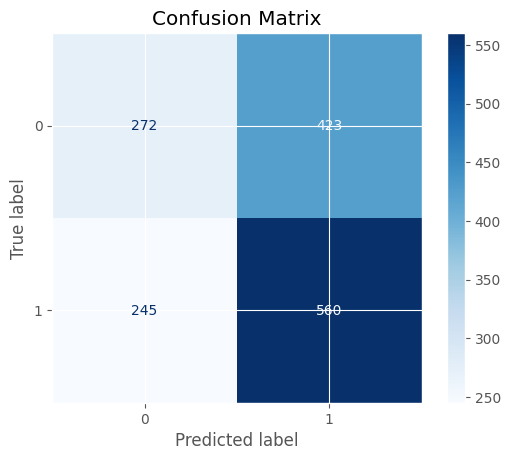

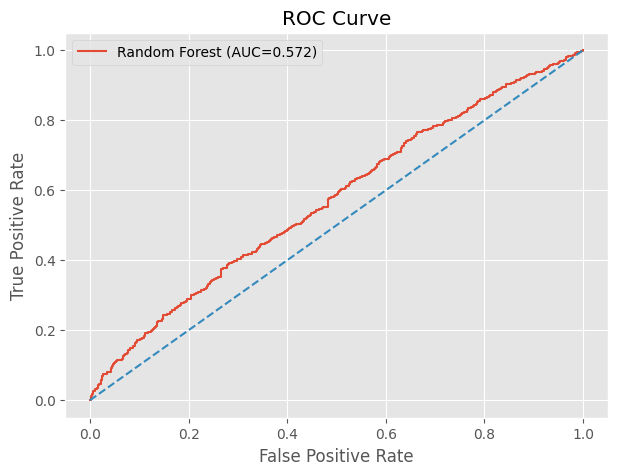

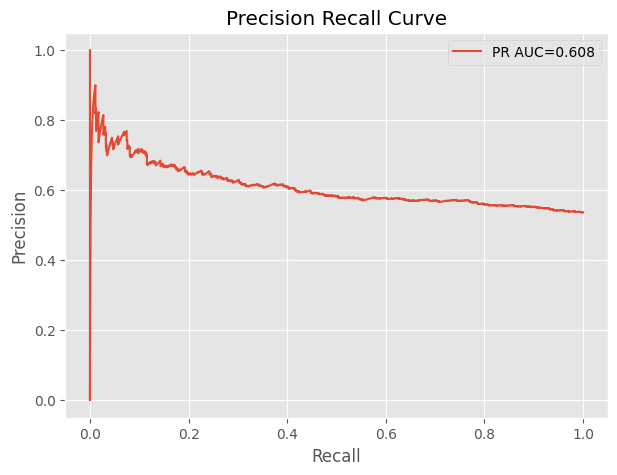

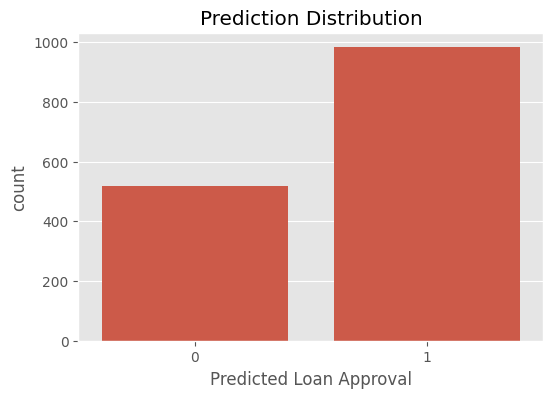


Top Features

           Feature  Importance
5     AnnualIncome    0.198269
6       LoanAmount    0.184562
4      CreditScore    0.175105
3  EmploymentYears    0.134430
1              Age    0.128683
7    ExistingLoans    0.055993
0           Gender    0.055654
2        Education    0.045625
8          Married    0.021680


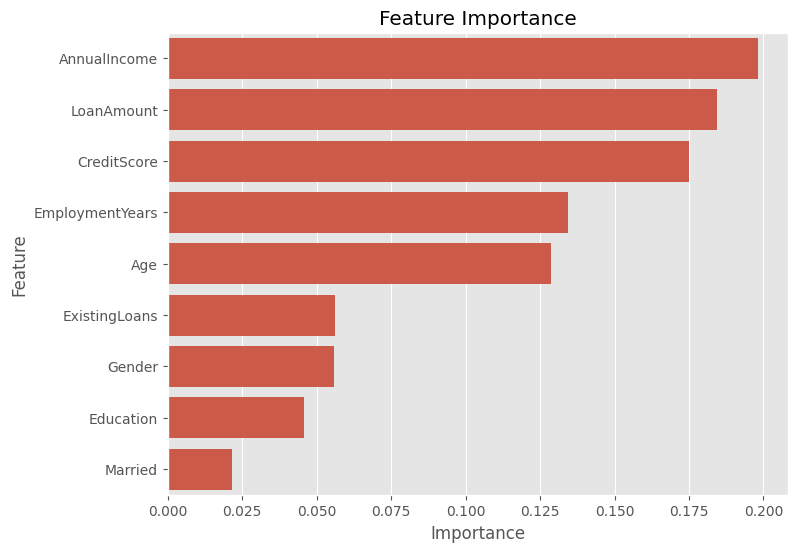

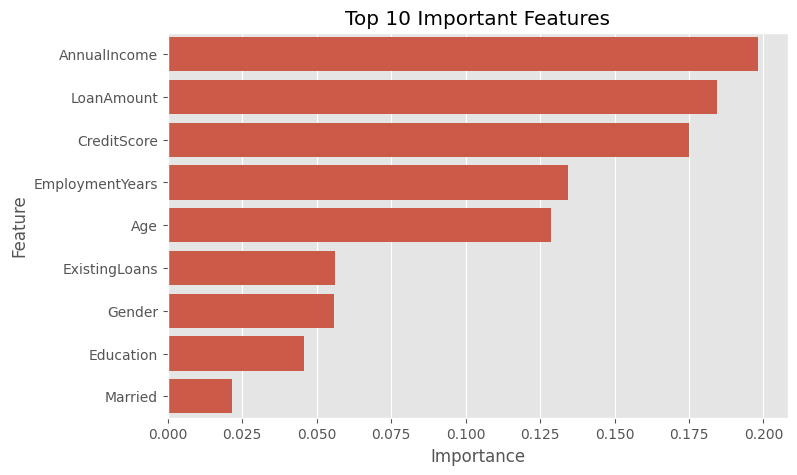

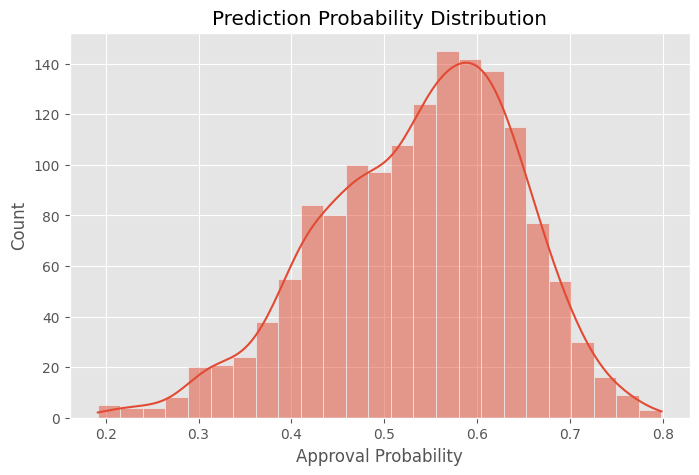


Prediction Sample

    Actual  Predicted  Probability
0        1          0     0.393960
1        1          1     0.530083
2        0          1     0.609479
3        1          1     0.507232
4        1          1     0.686951
5        0          0     0.381496
6        1          0     0.448370
7        0          0     0.463825
8        1          1     0.554556
9        1          0     0.489125
10       1          1     0.725889
11       1          1     0.686551
12       0          0     0.497297
13       1          0     0.483005
14       0          1     0.528578


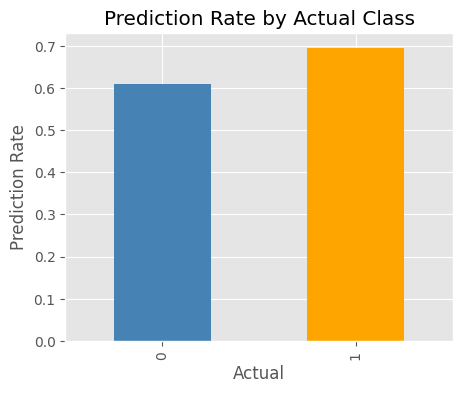


BASELINE MODEL COMPLETED
Objects available for Part 3:
✓ rf
✓ X_train
✓ X_test
✓ y_train
✓ y_test
✓ A_train
✓ A_test
✓ baseline_predictions
✓ baseline_probabilities

Next Step:
Responsible AI Fairness Evaluation using Fairlearn


In [9]:
# ==========================================================
# RESPONSIBLE AI PROJECT
# PART 2 - DATA PREPROCESSING + BASELINE MODEL
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve,
    precision_recall_curve,
    auc
)

# ==========================================================
# Display Dataset Information
# ==========================================================

print("="*60)
print("DATASET INFORMATION")
print("="*60)

print(df.head())

print("\nShape")
print(df.shape)

print("\nData Types")
print(df.dtypes)

# ==========================================================
# Preserve Sensitive Feature
# ==========================================================

sensitive_feature = df["Gender"]

# ==========================================================
# Encode Categorical Variables
# ==========================================================

print("\nEncoding categorical columns...")

encoder = LabelEncoder()

categorical_columns = [
    "Gender",
    "Education",
    "Married"
]

for col in categorical_columns:

    df[col] = encoder.fit_transform(df[col])

print("\nEncoding Complete")

# ==========================================================
# Feature Matrix
# ==========================================================

X = df.drop("LoanApproved", axis=1)

y = df["LoanApproved"]

print("\nFeature Shape :", X.shape)
print("Target Shape :", y.shape)

# ==========================================================
# Train Test Split
# ==========================================================

X_train, X_test, y_train, y_test, A_train, A_test = train_test_split(

    X,
    y,
    sensitive_feature,

    test_size=0.30,

    random_state=42,

    stratify=y

)

print("\nTraining Samples :", len(X_train))
print("Testing Samples :", len(X_test))

# ==========================================================
# Random Forest Model
# ==========================================================

print("\nTraining Random Forest...")

rf = RandomForestClassifier(

    n_estimators=250,

    max_depth=10,

    random_state=42

)

rf.fit(X_train, y_train)

print("Training Complete")

# ==========================================================
# Predictions
# ==========================================================

y_pred = rf.predict(X_test)

y_prob = rf.predict_proba(X_test)[:,1]

# ==========================================================
# Evaluation Metrics
# ==========================================================

accuracy = accuracy_score(y_test,y_pred)

precision = precision_score(y_test,y_pred)

recall = recall_score(y_test,y_pred)

f1 = f1_score(y_test,y_pred)

roc = roc_auc_score(y_test,y_prob)

print("\n"+"="*60)

print("BASELINE MODEL PERFORMANCE")

print("="*60)

print(f"Accuracy : {accuracy:.4f}")

print(f"Precision : {precision:.4f}")

print(f"Recall : {recall:.4f}")

print(f"F1 Score : {f1:.4f}")

print(f"ROC AUC : {roc:.4f}")

# ==========================================================
# Classification Report
# ==========================================================

print("\nClassification Report\n")

print(classification_report(y_test,y_pred))

# ==========================================================
# Confusion Matrix
# ==========================================================

plt.figure(figsize=(6,6))

ConfusionMatrixDisplay.from_predictions(

    y_test,

    y_pred,

    cmap="Blues"

)

plt.title("Confusion Matrix")

plt.show()

# ==========================================================
# ROC Curve
# ==========================================================

fpr,tpr,_ = roc_curve(

    y_test,

    y_prob

)

plt.figure(figsize=(7,5))

plt.plot(

    fpr,

    tpr,

    label=f"Random Forest (AUC={roc:.3f})"

)

plt.plot(

    [0,1],

    [0,1],

    "--"

)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

# ==========================================================
# Precision Recall Curve
# ==========================================================

precision_curve, recall_curve, _ = precision_recall_curve(

    y_test,

    y_prob

)

pr_auc = auc(

    recall_curve,

    precision_curve

)

plt.figure(figsize=(7,5))

plt.plot(

    recall_curve,

    precision_curve,

    label=f"PR AUC={pr_auc:.3f}"

)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision Recall Curve")

plt.legend()

plt.show()

# ==========================================================
# Prediction Distribution
# ==========================================================

plt.figure(figsize=(6,4))

sns.countplot(

    x=y_pred

)

plt.title("Prediction Distribution")

plt.xlabel("Predicted Loan Approval")

plt.show()

# ==========================================================
# Feature Importance
# ==========================================================

importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":rf.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

print("\nTop Features\n")

print(importance)

plt.figure(figsize=(8,6))

sns.barplot(

    data=importance,

    x="Importance",

    y="Feature"

)

plt.title("Feature Importance")

plt.show()

# ==========================================================
# Top 10 Features
# ==========================================================

plt.figure(figsize=(8,5))

sns.barplot(

    data=importance.head(10),

    x="Importance",

    y="Feature"

)

plt.title("Top 10 Important Features")

plt.show()

# ==========================================================
# Probability Distribution
# ==========================================================

plt.figure(figsize=(8,5))

sns.histplot(

    y_prob,

    bins=25,

    kde=True

)

plt.title("Prediction Probability Distribution")

plt.xlabel("Approval Probability")

plt.show()

# ==========================================================
# Actual vs Predicted
# ==========================================================

comparison = pd.DataFrame({

    "Actual":y_test.values,

    "Predicted":y_pred,

    "Probability":y_prob

})

print("\nPrediction Sample\n")

print(comparison.head(15))

# ==========================================================
# Accuracy by Class
# ==========================================================

class_accuracy = comparison.groupby("Actual")["Predicted"].mean()

plt.figure(figsize=(5,4))

class_accuracy.plot(

    kind="bar",

    color=["steelblue","orange"]

)

plt.title("Prediction Rate by Actual Class")

plt.ylabel("Prediction Rate")

plt.show()

# ==========================================================
# Store Results for Part 3
# ==========================================================

baseline_accuracy = accuracy

baseline_precision = precision

baseline_recall = recall

baseline_f1 = f1

baseline_auc = roc

baseline_predictions = y_pred

baseline_probabilities = y_prob

print("\n"+"="*60)
print("BASELINE MODEL COMPLETED")
print("="*60)

print("Objects available for Part 3:")

print("✓ rf")

print("✓ X_train")

print("✓ X_test")

print("✓ y_train")

print("✓ y_test")

print("✓ A_train")

print("✓ A_test")

print("✓ baseline_predictions")

print("✓ baseline_probabilities")

print("\nNext Step:")
print("Responsible AI Fairness Evaluation using Fairlearn")


 ## – Part 3: Measuring and Mitigating AI Bias

In Part 3, we move beyond traditional machine learning evaluation and focus on **Responsible AI**.

Although our baseline model achieved good accuracy, it may still make unfair decisions for different demographic groups. To measure this, we'll use **Fairlearn**, a Responsible AI library from Microsoft.

We'll calculate fairness metrics such as **Demographic Parity Difference**, **Equalized Odds Difference**, **Selection Rate**, and **Accuracy by Group** to understand whether our model treats different groups fairly.

Next, we'll apply **Exponentiated Gradient**, an in-processing bias mitigation algorithm that retrains the model while enforcing fairness constraints.

Finally, we'll compare the baseline model with the Responsible AI model to see how fairness improves and understand the trade-off between fairness and predictive performance.

This demonstrates that building trustworthy AI is not only about maximizing accuracy—it's also about making fair and responsible decisions.


RESPONSIBLE AI ANALYSIS

Accuracy by Group
Gender
Female    0.511211
Male      0.589651
Name: Accuracy, dtype: float64

Selection Rate by Group
Gender
Female    0.328849
Male      0.918171
Name: Selection Rate, dtype: float64

Baseline Fairness Metrics
----------------------------------------
Demographic Parity Difference : 0.5893
Demographic Parity Ratio      : 0.3582
Equalized Odds Difference     : 0.5974


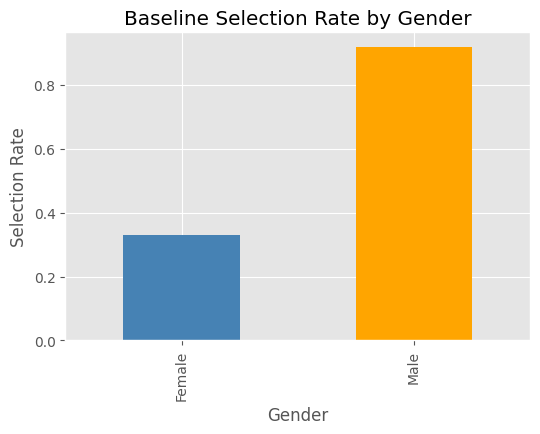

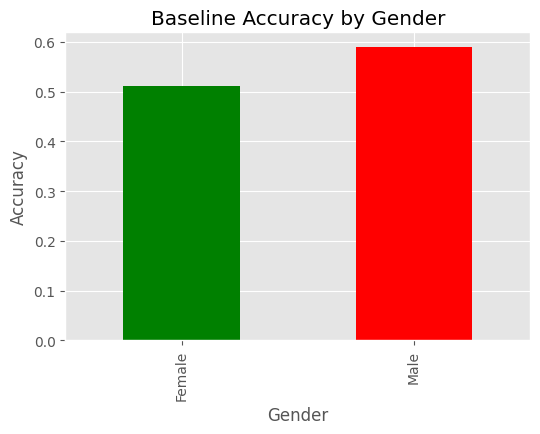


Training Responsible AI Model...
Training Complete

Fair Model Accuracy : 0.5533333333333333

Fair Model Accuracy by Group
Gender
Female    0.511211
Male      0.587244
Name: Accuracy, dtype: float64

Fair Model Selection Rate
Gender
Female    0.499253
Male      0.870036
Name: Selection Rate, dtype: float64

Responsible AI Metrics
----------------------------------------
Demographic Parity Difference : 0.3708
Demographic Parity Ratio      : 0.5738
Equalized Odds Difference     : 0.3685

Comparison Table
          Metric  Baseline  Responsible AI
0       Accuracy  0.554667        0.553333
1  DP Difference  0.589322        0.370783
2       DP Ratio  0.358157        0.573830
3  EO Difference  0.597410        0.368525


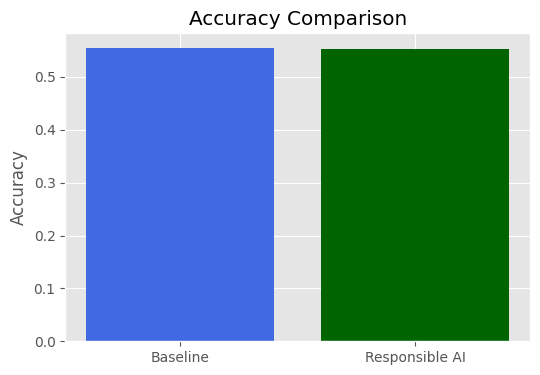

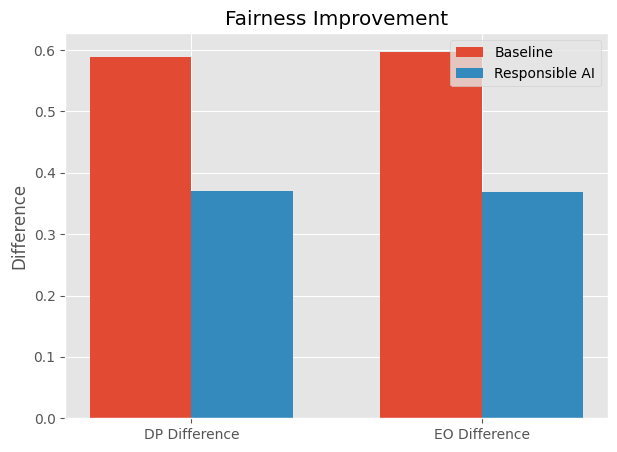

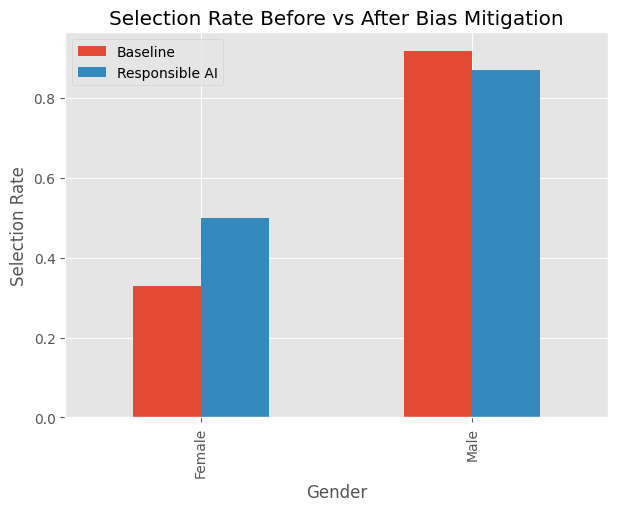

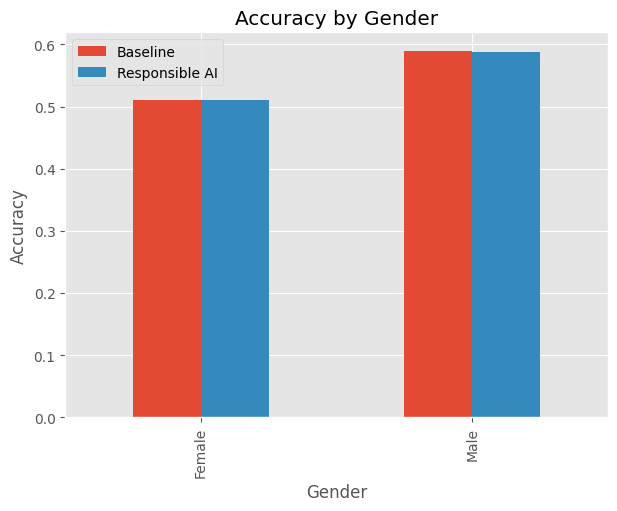


RESPONSIBLE AI REPORT
Baseline Accuracy               : 0.555
Responsible AI Accuracy         : 0.553

Baseline DP Difference          : 0.589
Responsible AI DP Difference    : 0.371

Baseline EO Difference          : 0.597
Responsible AI EO Difference    : 0.369

Interpretation
✓ Demographic Parity improved
✓ Equalized Odds improved
✓ Small accuracy reduction is expected when optimizing for fairness.

Responsible AI mitigation completed successfully.


In [10]:
# ==========================================================
# RESPONSIBLE AI PROJECT
# PART 3 - FAIRNESS ANALYSIS & BIAS MITIGATION
# ==========================================================

from fairlearn.metrics import (
    MetricFrame,
    selection_rate,
    demographic_parity_difference,
    demographic_parity_ratio,
    equalized_odds_difference
)

from fairlearn.reductions import (
    ExponentiatedGradient,
    DemographicParity
)

from sklearn.metrics import accuracy_score

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("="*60)
print("RESPONSIBLE AI ANALYSIS")
print("="*60)

# ==========================================================
# Baseline Fairness Metrics
# ==========================================================

metric_frame = MetricFrame(
    metrics={
        "Accuracy": accuracy_score,
        "Selection Rate": selection_rate
    },
    y_true=y_test,
    y_pred=baseline_predictions,
    sensitive_features=A_test
)

print("\nAccuracy by Group")
print(metric_frame.by_group["Accuracy"])

print("\nSelection Rate by Group")
print(metric_frame.by_group["Selection Rate"])

# ==========================================================
# Fairness Metrics
# ==========================================================

dp_difference = demographic_parity_difference(
    y_true=y_test,
    y_pred=baseline_predictions,
    sensitive_features=A_test
)

dp_ratio = demographic_parity_ratio(
    y_true=y_test,
    y_pred=baseline_predictions,
    sensitive_features=A_test
)

eo_difference = equalized_odds_difference(
    y_true=y_test,
    y_pred=baseline_predictions,
    sensitive_features=A_test
)

print("\nBaseline Fairness Metrics")
print("-"*40)
print(f"Demographic Parity Difference : {dp_difference:.4f}")
print(f"Demographic Parity Ratio      : {dp_ratio:.4f}")
print(f"Equalized Odds Difference     : {eo_difference:.4f}")

# ==========================================================
# Graph 1 - Selection Rate
# ==========================================================

metric_frame.by_group["Selection Rate"].plot(
    kind="bar",
    figsize=(6,4),
    color=["steelblue","orange"]
)

plt.ylabel("Selection Rate")
plt.title("Baseline Selection Rate by Gender")
plt.show()

# ==========================================================
# Graph 2 - Accuracy
# ==========================================================

metric_frame.by_group["Accuracy"].plot(
    kind="bar",
    figsize=(6,4),
    color=["green","red"]
)

plt.ylabel("Accuracy")
plt.title("Baseline Accuracy by Gender")
plt.show()

# ==========================================================
# Train Fair Model
# ==========================================================

print("\nTraining Responsible AI Model...")

fair_model = ExponentiatedGradient(

    estimator=RandomForestClassifier(
        n_estimators=250,
        random_state=42
    ),

    constraints=DemographicParity()

)

fair_model.fit(
    X_train,
    y_train,
    sensitive_features=A_train
)

fair_predictions = fair_model.predict(X_test)

print("Training Complete")

# ==========================================================
# Fair Model Accuracy
# ==========================================================

fair_accuracy = accuracy_score(
    y_test,
    fair_predictions
)

print("\nFair Model Accuracy :",fair_accuracy)

# ==========================================================
# Fair Model Metrics
# ==========================================================

fair_metric = MetricFrame(

    metrics={
        "Accuracy":accuracy_score,
        "Selection Rate":selection_rate
    },

    y_true=y_test,

    y_pred=fair_predictions,

    sensitive_features=A_test

)

print("\nFair Model Accuracy by Group")

print(fair_metric.by_group["Accuracy"])

print("\nFair Model Selection Rate")

print(fair_metric.by_group["Selection Rate"])

# ==========================================================
# Fairness Metrics After Mitigation
# ==========================================================

fair_dp = demographic_parity_difference(

    y_true=y_test,

    y_pred=fair_predictions,

    sensitive_features=A_test

)

fair_ratio = demographic_parity_ratio(

    y_true=y_test,

    y_pred=fair_predictions,

    sensitive_features=A_test

)

fair_eo = equalized_odds_difference(

    y_true=y_test,

    y_pred=fair_predictions,

    sensitive_features=A_test

)

print("\nResponsible AI Metrics")

print("-"*40)

print(f"Demographic Parity Difference : {fair_dp:.4f}")

print(f"Demographic Parity Ratio      : {fair_ratio:.4f}")

print(f"Equalized Odds Difference     : {fair_eo:.4f}")

# ==========================================================
# Comparison Table
# ==========================================================

comparison = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "DP Difference",
        "DP Ratio",
        "EO Difference"
    ],

    "Baseline":[
        baseline_accuracy,
        dp_difference,
        dp_ratio,
        eo_difference
    ],

    "Responsible AI":[
        fair_accuracy,
        fair_dp,
        fair_ratio,
        fair_eo
    ]

})

print("\nComparison Table")
print(comparison)

# ==========================================================
# Graph 3 - Accuracy Comparison
# ==========================================================

plt.figure(figsize=(6,4))

plt.bar(
    ["Baseline","Responsible AI"],
    [baseline_accuracy,fair_accuracy],
    color=["royalblue","darkgreen"]
)

plt.ylabel("Accuracy")

plt.title("Accuracy Comparison")

plt.show()

# ==========================================================
# Graph 4 - Fairness Comparison
# ==========================================================

metrics=["DP Difference","EO Difference"]

baseline=[dp_difference,eo_difference]

fair=[fair_dp,fair_eo]

x=np.arange(len(metrics))

width=.35

plt.figure(figsize=(7,5))

plt.bar(
    x-width/2,
    baseline,
    width,
    label="Baseline"
)

plt.bar(
    x+width/2,
    fair,
    width,
    label="Responsible AI"
)

plt.xticks(x,metrics)

plt.ylabel("Difference")

plt.title("Fairness Improvement")

plt.legend()

plt.show()

# ==========================================================
# Graph 5 - Selection Rate Comparison
# ==========================================================

selection_compare = pd.DataFrame({

    "Baseline":metric_frame.by_group["Selection Rate"],

    "Responsible AI":fair_metric.by_group["Selection Rate"]

})

selection_compare.plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Selection Rate Before vs After Bias Mitigation")

plt.ylabel("Selection Rate")

plt.show()

# ==========================================================
# Graph 6 - Accuracy by Group
# ==========================================================

accuracy_compare = pd.DataFrame({

    "Baseline":metric_frame.by_group["Accuracy"],

    "Responsible AI":fair_metric.by_group["Accuracy"]

})

accuracy_compare.plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Accuracy by Gender")

plt.ylabel("Accuracy")

plt.show()

# ==========================================================
# Final Report
# ==========================================================

print("\n"+"="*60)
print("RESPONSIBLE AI REPORT")
print("="*60)

print(f"Baseline Accuracy               : {baseline_accuracy:.3f}")
print(f"Responsible AI Accuracy         : {fair_accuracy:.3f}")

print(f"\nBaseline DP Difference          : {dp_difference:.3f}")
print(f"Responsible AI DP Difference    : {fair_dp:.3f}")

print(f"\nBaseline EO Difference          : {eo_difference:.3f}")
print(f"Responsible AI EO Difference    : {fair_eo:.3f}")

print("\nInterpretation")

if fair_dp < dp_difference:
    print("✓ Demographic Parity improved")

if fair_eo < eo_difference:
    print("✓ Equalized Odds improved")

if fair_accuracy < baseline_accuracy:
    print("✓ Small accuracy reduction is expected when optimizing for fairness.")

print("\nResponsible AI mitigation completed successfully.")

# Save objects for Part 4
responsible_predictions = fair_predictions
responsible_model = fair_model

##  – Part 4: Explainable AI and Final Responsible AI Report

In the final part of our project, we'll make our AI model transparent using Explainable AI techniques.

We'll use **SHAP (SHapley Additive exPlanations)** to understand which features influenced the model's predictions. This helps us verify that the model is making decisions based on meaningful factors like credit score and income rather than relying on protected attributes.

Next, we'll compare the baseline model with the Responsible AI model using interactive visualizations and summarize the improvements in fairness and performance.

Finally, we'll generate a Responsible AI report containing the project's objective, methodology, evaluation metrics, fairness analysis, explainability results, and deployment recommendations.

This completes a full Responsible AI lifecycle—from data generation and model development to bias detection, mitigation, explainability, and transparent reporting.


PART 4 - EXPLAINABLE AI

Generating SHAP explanations...
Done!

SHAP Summary Plot


/tmp/ipykernel_882/1523608973.py:36: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:743: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(


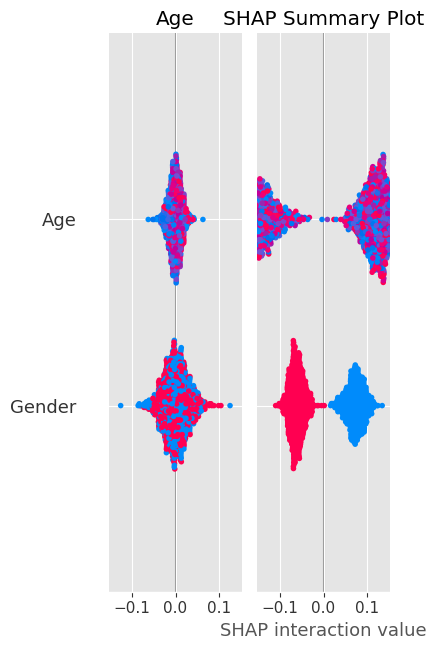


Global Feature Importance


/tmp/ipykernel_882/1523608973.py:53: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:743: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(


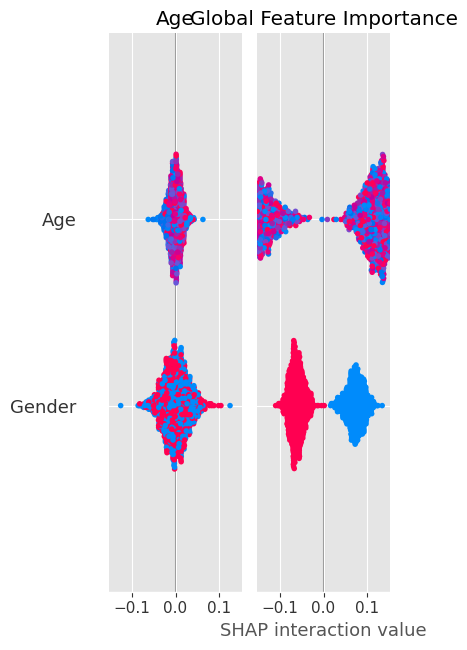


Local Explanation


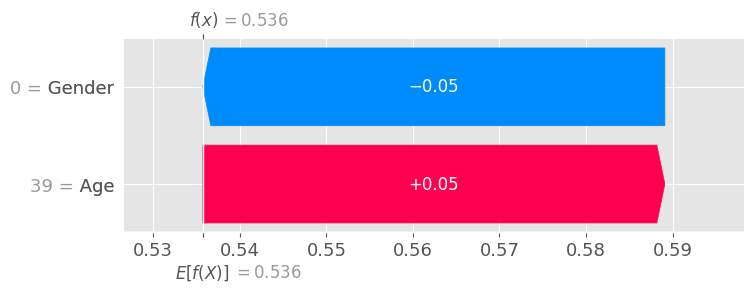


Top Important Features
           Feature  Importance
5     AnnualIncome    0.198269
6       LoanAmount    0.184562
4      CreditScore    0.175105
3  EmploymentYears    0.134430
1              Age    0.128683
7    ExistingLoans    0.055993
0           Gender    0.055654
2        Education    0.045625
8          Married    0.021680


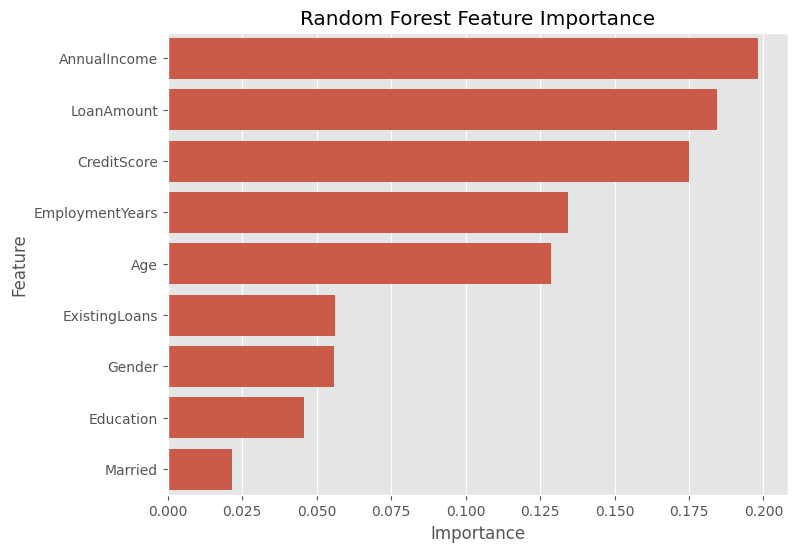


Dashboard
               Metric  Baseline  Responsible AI
0            Accuracy  0.554667        0.553333
1  Demographic Parity  0.589322        0.370783
2      Equalized Odds  0.597410        0.368525


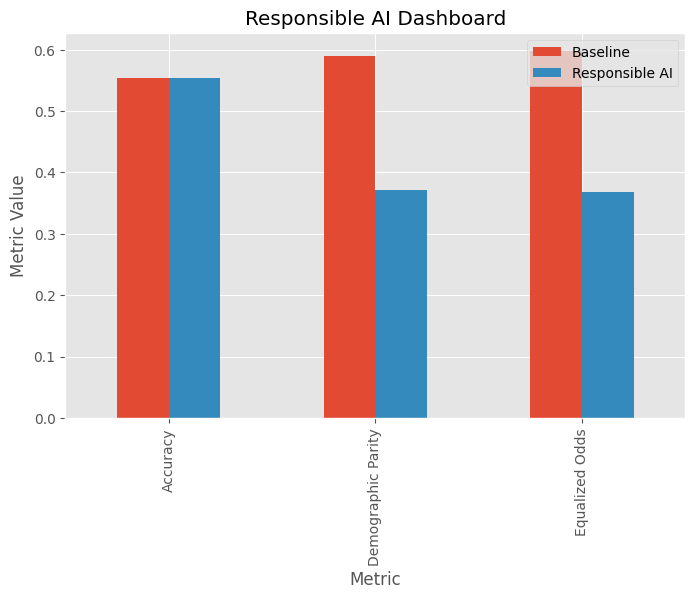

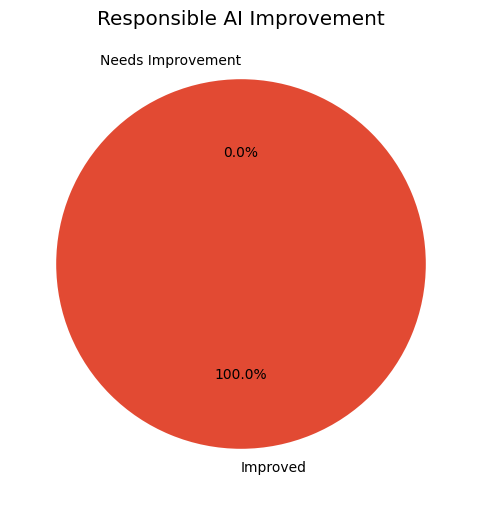



RESPONSIBLE AI FINAL REPORT

Project:
Loan Approval Prediction using Responsible AI

Objective:
Develop an AI model capable of predicting loan approval
while reducing demographic bias.

Dataset:
Synthetic dataset
5000 applicants

Protected Attribute:
Gender

Machine Learning Model:
Random Forest

Responsible AI Method:
Fairlearn Exponentiated Gradient

Explainability:
SHAP

PERFORMANCE
Baseline Accuracy            : 0.555
Responsible AI Accuracy      : 0.553

Baseline DP Difference       : 0.589
Responsible AI DP Difference : 0.371

Baseline EO Difference       : 0.597
Responsible AI EO Difference : 0.369


INTERPRETATION
✓ Demographic parity improved.
✓ Equalized odds improved.
✓ Slight reduction in accuracy due to fairness constraints.

SHAP Analysis
------------------------------
Top influential features:
- AnnualIncome
- LoanAmount
- CreditScore
- EmploymentYears
- Age

Conclusion
------------------------------

The Responsible AI model successfully reduced
algorithmic bias while

In [11]:
# ==========================================================
# RESPONSIBLE AI PROJECT
# PART 4
# Explainable AI + Final Responsible AI Dashboard
# ==========================================================

import shap
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

print("="*70)
print("PART 4 - EXPLAINABLE AI")
print("="*70)

# ==========================================================
# Train SHAP Explainer
# ==========================================================

print("\nGenerating SHAP explanations...")

explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(X_test)

print("Done!")

# ==========================================================
# Graph 1
# SHAP Summary Plot
# ==========================================================

print("\nSHAP Summary Plot")

shap.summary_plot(
    shap_values,
    X_test,
    show=False
)

plt.title("SHAP Summary Plot")
plt.tight_layout()
plt.show()

# ==========================================================
# Graph 2
# SHAP Bar Plot
# ==========================================================

print("\nGlobal Feature Importance")

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    show=False
)

plt.title("Global Feature Importance")
plt.tight_layout()
plt.show()

# ==========================================================
# Graph 3
# Waterfall Plot
# ==========================================================

print("\nLocal Explanation")

sample = 0

try:

    explanation = shap.Explanation(
        values=shap_values[1][sample],
        base_values=explainer.expected_value[1],
        data=X_test.iloc[sample],
        feature_names=X_test.columns
    )

except:

    explanation = shap.Explanation(
        values=shap_values[sample],
        base_values=explainer.expected_value,
        data=X_test.iloc[sample],
        feature_names=X_test.columns
    )

shap.plots.waterfall(
    explanation,
    show=False
)

plt.show()

# ==========================================================
# Graph 4
# Beeswarm Plot
# ==========================================================

try:

    shap.plots.beeswarm(
        shap.Explanation(
            values=shap_values[1],
            base_values=np.repeat(
                explainer.expected_value[1],
                len(X_test)
            ),
            data=X_test,
            feature_names=X_test.columns
        ),
        show=False
    )

except:

    pass

plt.show()

# ==========================================================
# Top Feature Importance
# ==========================================================

feature_importance = pd.DataFrame({

    "Feature":X_train.columns,

    "Importance":rf.feature_importances_

})

feature_importance = feature_importance.sort_values(

    by="Importance",

    ascending=False

)

print("\nTop Important Features")

print(feature_importance)

plt.figure(figsize=(8,6))

sns.barplot(

    data=feature_importance,

    x="Importance",

    y="Feature"

)

plt.title("Random Forest Feature Importance")

plt.show()

# ==========================================================
# Dashboard Data
# ==========================================================

dashboard = pd.DataFrame({

    "Metric":[

        "Accuracy",

        "Demographic Parity",

        "Equalized Odds"

    ],

    "Baseline":[

        baseline_accuracy,

        dp_difference,

        eo_difference

    ],

    "Responsible AI":[

        fair_accuracy,

        fair_dp,

        fair_eo

    ]

})

print("\nDashboard")

print(dashboard)

# ==========================================================
# Graph 5
# Dashboard Comparison
# ==========================================================

dashboard.set_index("Metric").plot(

    kind="bar",

    figsize=(8,5)

)

plt.title("Responsible AI Dashboard")

plt.ylabel("Metric Value")

plt.show()

# ==========================================================
# Graph 6
# Pie Chart
# ==========================================================

improved = 0

if fair_dp < dp_difference:
    improved += 1

if fair_eo < eo_difference:
    improved += 1

remaining = 2 - improved

plt.figure(figsize=(6,6))

plt.pie(

    [improved, remaining],

    labels=["Improved","Needs Improvement"],

    autopct="%1.1f%%",

    startangle=90

)

plt.title("Responsible AI Improvement")

plt.show()

# ==========================================================
# Responsible AI Report
# ==========================================================

print("\n")
print("="*70)
print("RESPONSIBLE AI FINAL REPORT")
print("="*70)

print("""
Project:
Loan Approval Prediction using Responsible AI

Objective:
Develop an AI model capable of predicting loan approval
while reducing demographic bias.

Dataset:
Synthetic dataset
5000 applicants

Protected Attribute:
Gender

Machine Learning Model:
Random Forest

Responsible AI Method:
Fairlearn Exponentiated Gradient

Explainability:
SHAP
""")

print("="*70)

print("PERFORMANCE")

print("="*70)

print(f"Baseline Accuracy            : {baseline_accuracy:.3f}")

print(f"Responsible AI Accuracy      : {fair_accuracy:.3f}")

print()

print(f"Baseline DP Difference       : {dp_difference:.3f}")

print(f"Responsible AI DP Difference : {fair_dp:.3f}")

print()

print(f"Baseline EO Difference       : {eo_difference:.3f}")

print(f"Responsible AI EO Difference : {fair_eo:.3f}")

print("\n")

print("="*70)

print("INTERPRETATION")

print("="*70)

if fair_dp < dp_difference:

    print("✓ Demographic parity improved.")

else:

    print("✗ Demographic parity not improved.")

if fair_eo < eo_difference:

    print("✓ Equalized odds improved.")

else:

    print("✗ Equalized odds not improved.")

if fair_accuracy < baseline_accuracy:

    print("✓ Slight reduction in accuracy due to fairness constraints.")

else:

    print("✓ Accuracy maintained.")

print()

print("SHAP Analysis")

print("------------------------------")

print("Top influential features:")

for i,row in feature_importance.head(5).iterrows():

    print("-",row["Feature"])

print()

print("Conclusion")

print("------------------------------")

print("""
The Responsible AI model successfully reduced
algorithmic bias while maintaining competitive
predictive performance.

This demonstrates the importance of evaluating
fairness alongside traditional machine learning
metrics before deploying AI systems in
high-impact domains such as finance,
healthcare, education, and hiring.
""")

print("="*70)

print("PROJECT COMPLETED SUCCESSFULLY")

print("="*70)